# ML Rydberg Workflow

In [1]:
import qkernel
import numpy as np
import matplotlib.pyplot as plt
import snag
from sklearn.metrics import r2_score
from scipy.spatial.distance import pdist, squareform
from qkernel.utils import compute_excitation_count

## Generate Data

In [2]:
n_atoms = 4

def create_distortions(n, x_range):
    distances = np.random.uniform(1.0, 1.0+x_range, (n, n_atoms - 1))
    return np.column_stack((np.zeros(n), np.cumsum(distances, 1)))

In [3]:
q_train = np.concatenate(
    [
        create_distortions(100, 4), 
        create_distortions(100, 3), 
        create_distortions(10, 0.1), 
        create_distortions(10, 0.5),
        create_distortions(100, 1.),
        ]
    )
d_train = np.array([pdist(q[:, None]) for q in q_train])

q_test = create_distortions(100, 3)
d_test = np.array([pdist(q[:, None]) for q in q_test])

q_train.shape, q_test.shape, d_train.shape, d_test.shape

((320, 4), (100, 4), (320, 6), (100, 6))

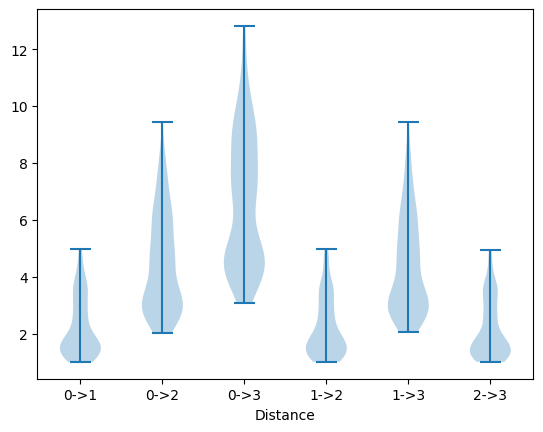

In [4]:
plt.violinplot(d_train, range(d_train.shape[1]))
plt.xlabel("Distance")
plt.xticks(
    range(d_train.shape[1]),
    [f"{i}->{j}" for i in range(n_atoms - 1) for j in range(i + 1, n_atoms)],
)
plt.show()

## Run Neutral Atom sims

In [5]:
def compute_probs(qs, scaling_fac=7):
    ham = qkernel.hamiltonian.QuTiPHamiltonian(qs * scaling_fac)
    sim = qkernel.simulator.QuTiPSimulator(ham.generate_hamiltonians_list())
    probs = np.array(sim.get_probabilities_list())[:, :, 0]
    return compute_excitation_count(probs)

In [6]:
p_train = compute_probs(q_train[:, :, None])
p_test = compute_probs(q_test[:, :, None])

kernel = qkernel.kernel.Kernel(p_train=p_train, distance_fn="exp_js")
g_train = kernel.compute_gram_train()
g_test = kernel.compute_gram_test(p_test=p_test)

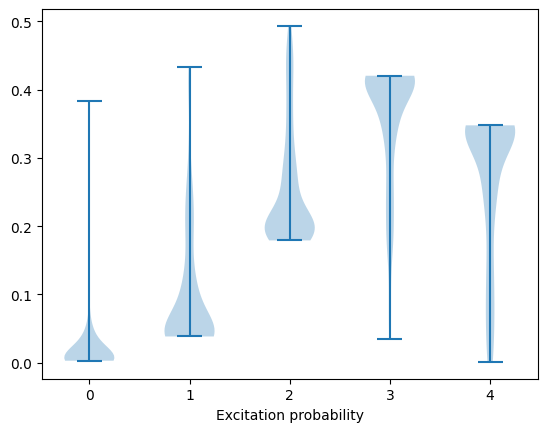

In [7]:
plt.violinplot(kernel.p_train)
plt.xticks(range(1, n_atoms + 2), range(n_atoms + 1))
plt.xlabel("Excitation probability")
plt.show()

## Solve Hubbard

In [8]:
calc = snag.Hubbard(n_up=1, n_dn=1, n_sites=n_atoms)
mol_calc = snag.HubbardMol(calc)

e_train = np.array([mol_calc.solve(d) for d in d_train])
e_test = np.array([mol_calc.solve(d) for d in d_test])

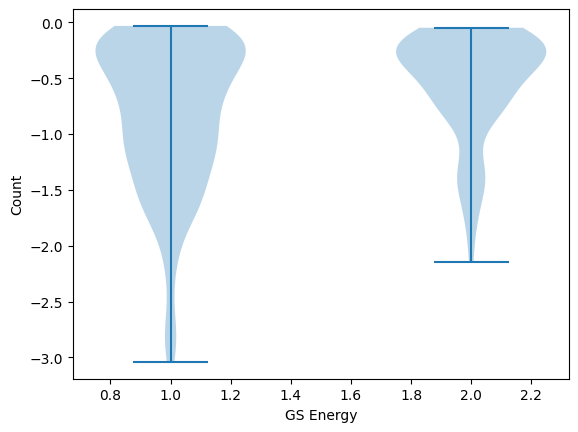

In [9]:
plt.violinplot([e_train, e_test])

plt.xlabel("GS Energy")
plt.ylabel("Count")
plt.show()

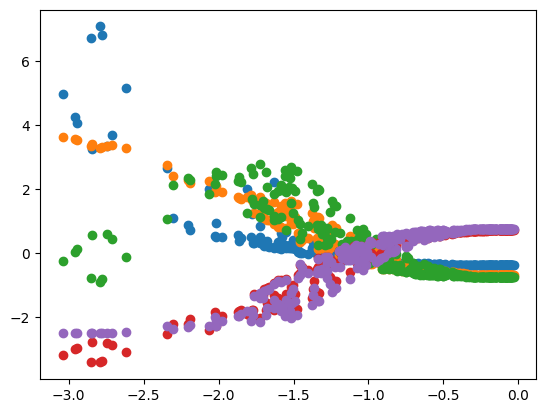

In [48]:
mu_train = e_train.mean()
sig_train = e_train.std()

e_train_s = (e_train - mu_train) / sig_train
e_test_s = (e_test - mu_train) / sig_train


for i in range(n_atoms + 1):
    p_train_i_s = (p_train[:, i] - np.mean(p_train[:, i])) / np.std(p_train[:, i])
    plt.scatter(e_train, p_train_i_s)

## Fit Model

In [49]:
import keras
from keras import layers
from keras import ops

In [79]:
# Define Sequential model with 3 layers
model = keras.Sequential(
    [
        keras.Input(shape=(n_atoms+1,)),
        layers.Dense(100, activation="relu", name="layer1"),
        layers.Dense(100, activation="relu", name="layer2"),
        layers.Dense(1, name="layer3"),
    ]
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.1),  # Optimizer
    # Loss function to minimize
    loss=keras.losses.MeanSquaredError(),
    # List of metrics to monitor
    metrics=[keras.losses.MeanSquaredError()],
)


print("Fit model on training data")
history = model.fit(
    p_train,
    e_train_s,
    batch_size=p_train.shape[0],
    epochs=400,
    # We pass some validation for
    # monitoring validation loss and metrics
    # at the end of each epoch
    validation_data=(p_test, e_test_s),
)

# # Call model on a test input
# x = ops.ones((4, 5))
# y = model(x)
# y


Fit model on training data
Epoch 1/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step - loss: 0.9814 - mean_squared_error: 0.9814 - val_loss: 0.8543 - val_mean_squared_error: 0.8543
Epoch 2/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.6483 - mean_squared_error: 0.6483 - val_loss: 63.6370 - val_mean_squared_error: 63.6370
Epoch 3/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 66.0639 - mean_squared_error: 66.0639 - val_loss: 2.1565 - val_mean_squared_error: 2.1565
Epoch 4/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 3.0913 - mean_squared_error: 3.0913 - val_loss: 5.0284 - val_mean_squared_error: 5.0284
Epoch 5/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 4.0668 - mean_squared_error: 4.0668 - val_loss: 4.4841 - val_mean_squared_error: 4.4841
Epoch 6/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 3.4886 - mean_squared_error: 3.4886 - val_loss: 1.5364 - val_mean_squared_error: 1.5364
Epoch 7/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.3416 - mean_squared_error: 1.341

In [80]:
# model = qkernel.model.KRR(alpha=1e-8)
# model.train(g_train, e_train)
# pred_train = model.predict(g_train)
# pred_test = model.predict(g_test)

pred_train = model.predict(p_train) * sig_train + mu_train
pred_test = model.predict(p_test) * sig_train + mu_train

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [81]:
print("r2 train:", r2_score(e_train, pred_train))
print("r2 test:", r2_score(e_test, pred_test))

r2 train: 0.9725943657354296
r2 test: 0.9489633494238774


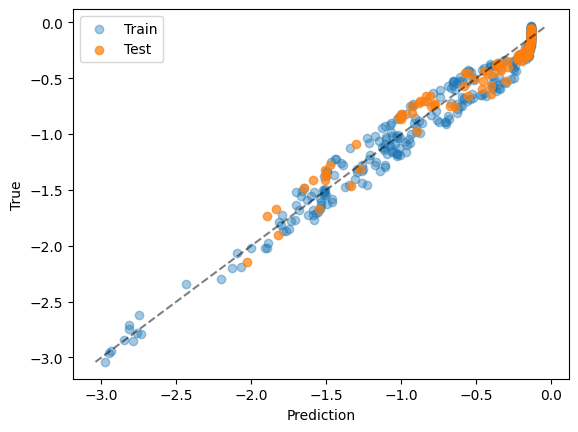

In [82]:
plt.scatter(pred_train, e_train, alpha=0.4, label="Train")
plt.scatter(pred_test, e_test, alpha=0.7, label="Test")
plt.xlabel("Prediction")
plt.ylabel("True")

bounds = [min(e_train), max(e_train)]
plt.legend()
plt.plot(bounds, bounds, ls="--", c="k", alpha=0.5)
plt.show()

## Generalization to separation

In [83]:
# 2*n chain bisection
n_chain = 4

ni_hoppings = squareform(
    snag.hubbard_mol.radial_hopping(pdist(np.arange(n_chain // 2)[:, None]))
)
non_int = snag.NonInteracting(ni_hoppings)
benchmark = 2 * non_int.total_energy(1, 0)

calc = snag.Hubbard(n_up=1, n_dn=1, n_sites=n_chain)
calc_mol = snag.HubbardMol(calc)

distortions = np.linspace(0.0, 1.5, 20)
energies = []
mols = []

for d in distortions:
    x = np.arange(n_chain, dtype=float)
    x[n_chain // 2 :] = x[n_chain // 2 :] + d
    mols.append(x)
    pds = pdist(x[:, None])
    energies.append(calc_mol.solve(pds))

mols = np.array(mols)

In [84]:
p_cd = compute_probs(mols[:, :, None])
pred_cd = model.predict(p_cd) * sig_train + mu_train
#pred_cd = model.predict(kernel.compute_gram_test(p_cd))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


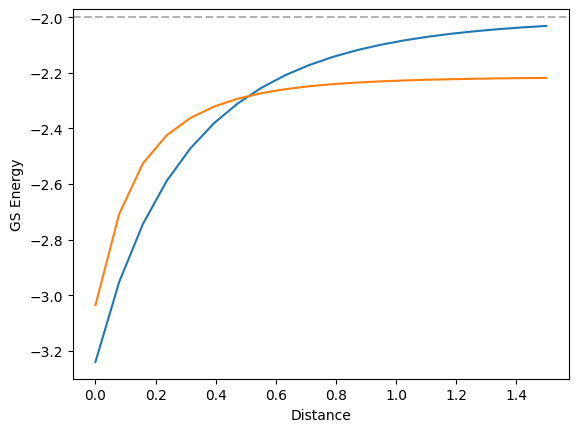

In [85]:
plt.plot(distortions, energies)
plt.plot(distortions, pred_cd)

plt.axhline(y=benchmark, ls="--", c="k", alpha=0.3)
plt.xlabel("Distance")
plt.ylabel("GS Energy")
plt.show()